In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = pd.read_csv(r'C:\Code_AI\AIO_Code\Module2\LinearRegression\boston_housing.csv')
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


Epoch 0: Loss = 17808729953.71
Epoch 100: Loss = nan
Epoch 200: Loss = nan
Epoch 300: Loss = nan
Epoch 400: Loss = nan
Epoch 500: Loss = nan
Epoch 600: Loss = nan
Epoch 700: Loss = nan
Epoch 800: Loss = nan
Epoch 900: Loss = nan
---------------------------------
Huấn luyện xong!
Loss cuối cùng (MSE): nan
Bias (theta[0]): nan
Các trọng số (weights) còn lại:
 [nan nan nan nan nan nan nan nan nan nan nan nan nan]


c:\Users\Nguyen\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Nguyen\AppData\Local\Temp\ipykernel_19440\2171632970.py:20: RuntimeWarning: overflow encountered in square
  return (1/n) * np.sum((y_hat - y) ** 2)


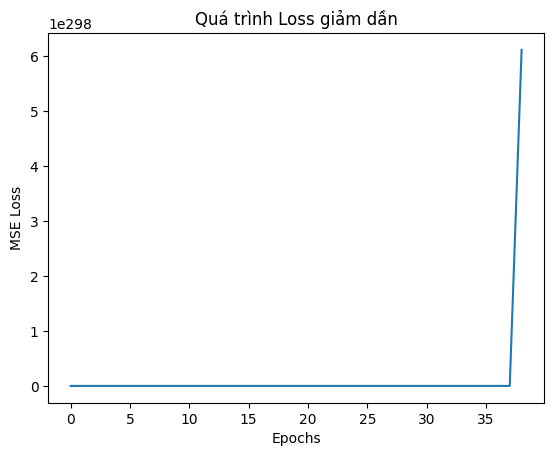

In [26]:
x_data = data.drop(['MEDV'], axis = 1)
y_data = data['MEDV']

X = x_data.values
y = y_data.values

X_b = np.c_[np.ones((len(X), 1)), X]

def predict(x, theta):
    return x.dot(theta)
def gradient(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    error = y_hat - y
    dtheta = (2 / n) * x.T.dot(error)
    return dtheta
def compute_loss(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    return (1/n) * np.sum((y_hat - y) ** 2)

m, n = X.shape
theta = np.zeros(n + 1)

learing_rate = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    gradients = gradient(X_b, y, theta)
    theta = theta - learing_rate * gradients

    loss = compute_loss(X_b, y, theta)
    loss_history.append(loss)

    if i % 100 == 0:
        print(f"Epoch {i}: Loss = {loss:.2f}")

print("---------------------------------")
print("Huấn luyện xong!")
print(f"Loss cuối cùng (MSE): {loss_history[-1]:.2f}")
print("Bias (theta[0]):", theta[0])
print("Các trọng số (weights) còn lại:\n", theta[1:])

# 6. Vẽ biểu đồ quá trình học (Loss giảm dần theo thời gian)
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Quá trình Loss giảm dần')
plt.show()

Hiện tượng này được gọi là "Gradient Explosion" (Bùng nổ Gradient). Đây là lý do tại sao Feature Scaling (Chuẩn hóa dữ liệu) gần như là bước bắt buộc trong các thuật toán dựa trên Gradient Descent.

**1. Sự chênh lệch quá lớn về giá trị (Scale)**

- Trong bộ dữ liệu Boston Housing:
    - Cột NOX (nồng độ oxit nitơ) chỉ khoảng 0.4 đến 0.8.
    - Cột TAX (thuế suất) có giá trị lên tới 600 đến 700.

**2. Điều gì xảy ra trong công thức Gradient?**

- Hãy nhìn vào công thức cập nhật của bạn: theta = theta - learning_rate * gradients
- Trong đó, gradient được tính dựa trên $X$:
dtheta = (2/n) * x.T.dot(error)
- Giả sử tại vòng lặp đầu tiên:
    - Tính Error: $y_{pred}$ ban đầu gần bằng 0 (vì theta=0), $y_{thuc}$ khoảng 20. $\rightarrow$ Error $\approx -20$.
    - Tính Gradient: Gradient tỉ lệ thuận với $X$.
        - Với cột TAX có giá trị là 666.
        - Gradient $\approx 666 \times (-20) \approx -13,320$ (số rất lớn).
    - Cập nhật Theta:
        - learning_rate của bạn là 0.01.
        - $\theta_{mới} = 0 - 0.01 \times (-13,320) = \mathbf{133.2}$.

**3. Vòng lặp "Tự sát" (Divergence)**

- Đến vòng lặp thứ 2, thảm họa bắt đầu:
    - Dự đoán lại: Bây giờ $\theta$ đã là 133.2. Khi nhân với $X$ (là 666):
        - $y_{pred} = 133.2 \times 666 \approx \mathbf{88,711}$.
    - Tính Error mới: $y_{thuc}$ vẫn là 20.
        - Error = $88,711 - 20 \approx \mathbf{88,691}$. (Lỗi tăng vọt từ 20 lên 88 ngàn!).
    - Tính Gradient mới:
        - Gradient $\approx 666 \times 88,691 \approx \mathbf{59,000,000}$.
        
**4. Cách khắc phục**

- Cách chuẩn (Khuyên dùng): Dùng StandardScaler.
- Cách chữa cháy (Không khuyên dùng): Giảm learning_rate xuống cực nhỏ để bù lại độ lớn của dữ liệu.
    - Bạn thử đổi learing_rate = 0.000001 (thêm 4-5 số 0 nữa) xem sao. Code sẽ chạy được, nhưng loss giảm cực kỳ chậm.

Epoch 0: Loss = 196.25
Epoch 1000: Loss = 72.49
Epoch 2000: Loss = 69.01
Epoch 3000: Loss = 66.69
Epoch 4000: Loss = 64.81
Epoch 5000: Loss = 63.19
Epoch 6000: Loss = 61.76
Epoch 7000: Loss = 60.47
Epoch 8000: Loss = 59.32
Epoch 9000: Loss = 58.28
---------------------------------
Huấn luyện xong!
Loss cuối cùng (MSE): 57.34
Bias (theta[0]): 0.011216208340819269
Các trọng số (weights) còn lại:
 [-0.09651301  0.12902119 -0.05825885  0.00741099  0.00407551  0.13198826
  0.0818834   0.01920698  0.01254062  0.00310853  0.0907662   0.04554314
 -0.33965396]


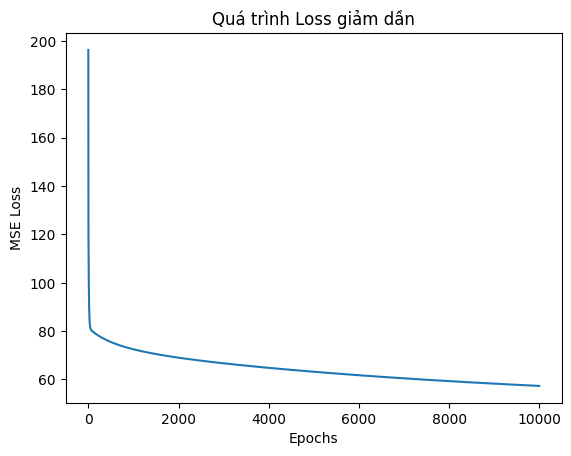

In [29]:
x_data = data.drop(['MEDV'], axis = 1)
y_data = data['MEDV']

X = x_data.values
y = y_data.values

X_b = np.c_[np.ones((len(X), 1)), X]

def predict(x, theta):
    return x.dot(theta)
def gradient(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    error = y_hat - y
    dtheta = (2 / n) * x.T.dot(error)
    return dtheta
def compute_loss(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    return (1/n) * np.sum((y_hat - y) ** 2)

m, n = X.shape
theta = np.zeros(n + 1)

learing_rate = 0.000001
epochs = 10000
loss_history = []

for i in range(epochs):
    gradients = gradient(X_b, y, theta)
    theta = theta - learing_rate * gradients

    loss = compute_loss(X_b, y, theta)
    loss_history.append(loss)

    if i % 1000 == 0:
        print(f"Epoch {i}: Loss = {loss:.2f}")

print("---------------------------------")
print("Huấn luyện xong!")
print(f"Loss cuối cùng (MSE): {loss_history[-1]:.2f}")
print("Bias (theta[0]):", theta[0])
print("Các trọng số (weights) còn lại:\n", theta[1:])

# 6. Vẽ biểu đồ quá trình học (Loss giảm dần theo thời gian)
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Quá trình Loss giảm dần')
plt.show()

Epoch 0: Loss = 563.43
Epoch 100: Loss = 32.51
Epoch 200: Loss = 23.04
Epoch 300: Loss = 22.50
Epoch 400: Loss = 22.29
Epoch 500: Loss = 22.16
Epoch 600: Loss = 22.08
Epoch 700: Loss = 22.03
Epoch 800: Loss = 22.00
Epoch 900: Loss = 21.97
---------------------------------
Huấn luyện xong!
Loss cuối cùng (MSE): 21.95
Bias (theta[0]): 22.532806286188695
Các trọng số (weights) còn lại:
 [-0.87243979  0.98514139 -0.0943792   0.71501668 -1.9387766   2.73738792
 -0.02848829 -3.05546651  2.04939371 -1.41239063 -2.02454969  0.85004707
 -3.71538521]


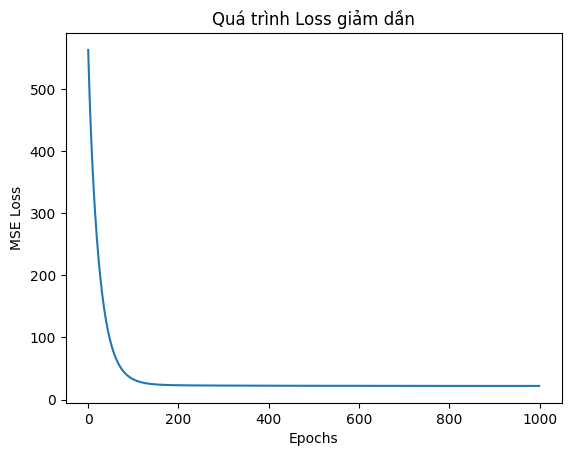

In [28]:
x_data = data.drop(['MEDV'], axis = 1)
y_data = data['MEDV']

X = x_data.values
y = y_data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

def predict(x, theta):
    return x.dot(theta)
def gradient(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    error = y_hat - y
    dtheta = (2 / n) * x.T.dot(error)
    return dtheta
def compute_loss(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    return (1/n) * np.sum((y_hat - y) ** 2)

m, n = X_scaled.shape
theta = np.zeros(n + 1)

learing_rate = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    gradients = gradient(X_b, y, theta)
    theta = theta - learing_rate * gradients

    loss = compute_loss(X_b, y, theta)
    loss_history.append(loss)

    if i % 100 == 0:
        print(f"Epoch {i}: Loss = {loss:.2f}")

print("---------------------------------")
print("Huấn luyện xong!")
print(f"Loss cuối cùng (MSE): {loss_history[-1]:.2f}")
print("Bias (theta[0]):", theta[0])
print("Các trọng số (weights) còn lại:\n", theta[1:])

# 6. Vẽ biểu đồ quá trình học (Loss giảm dần theo thời gian)
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Quá trình Loss giảm dần')
plt.show()

Mini-batch Gradient Descent

Bắt đầu huấn luyện Mini-Batch...
Epoch 0: Loss = 306.35
Epoch 10: Loss = 23.49
Epoch 20: Loss = 22.41
Epoch 30: Loss = 22.16
Epoch 40: Loss = 22.07
Epoch 50: Loss = 22.00
Epoch 60: Loss = 22.00
Epoch 70: Loss = 21.94
Epoch 80: Loss = 21.94
Epoch 90: Loss = 21.92
---------------------------------
Huấn luyện xong!
Loss cuối cùng: 21.94


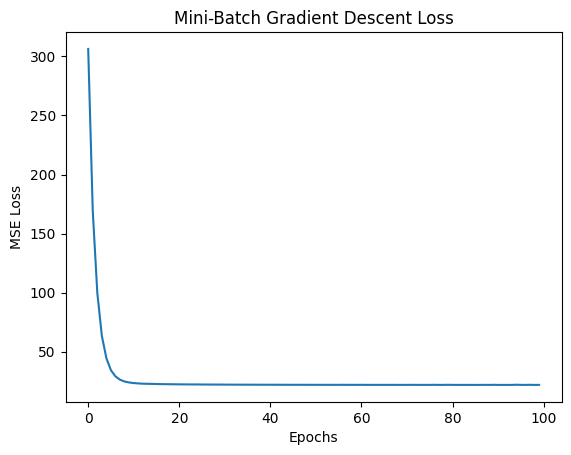

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- 1. CHUẨN BỊ DỮ LIỆU (Giữ nguyên) ---
x_data = data.drop(['MEDV'], axis = 1)
y_data = data['MEDV']

X = x_data.values
y = y_data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]


def predict(x, theta):
    return x.dot(theta)

def gradient(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    error = y_hat - y
    dtheta = (2 / n) * x.T.dot(error)
    return dtheta

def compute_loss(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    return (1/n) * np.sum((y_hat - y) ** 2)

# --- 3. THIẾT LẬP THAM SỐ ---
m, n = X_scaled.shape
theta = np.zeros(n + 1)

learning_rate = 0.01
epochs = 100    # Mini-batch hội tụ nhanh hơn nên có thể giảm epochs
batch_size = 32 # Kích thước mỗi batch (thường là 32, 64, 128)
loss_history = []

# --- 4. HUẤN LUYỆN VỚI MINI-BATCH ---
print("Bắt đầu huấn luyện Mini-Batch...")

for epoch in range(epochs):
    
    # A. Xáo trộn dữ liệu (Shuffling) - BẮT BUỘC
    indices = np.random.permutation(m)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]
    
    # B. Duyệt qua từng Batch
    for i in range(0, m, batch_size):
        # Cắt lấy mini-batch
        xi = X_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        
        # Tính gradient và cập nhật TRÊN BATCH ĐÓ
        gradients = gradient(xi, yi, theta)
        theta = theta - learning_rate * gradients
        
    # C. Tính Loss trên TOÀN BỘ dữ liệu để theo dõi (Optional)
    total_loss = compute_loss(X_b, y, theta)
    loss_history.append(total_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss:.2f}")

print("---------------------------------")
print("Huấn luyện xong!")
print(f"Loss cuối cùng: {loss_history[-1]:.2f}")

# 5. Vẽ biểu đồ
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Mini-Batch Gradient Descent Loss')
plt.show()

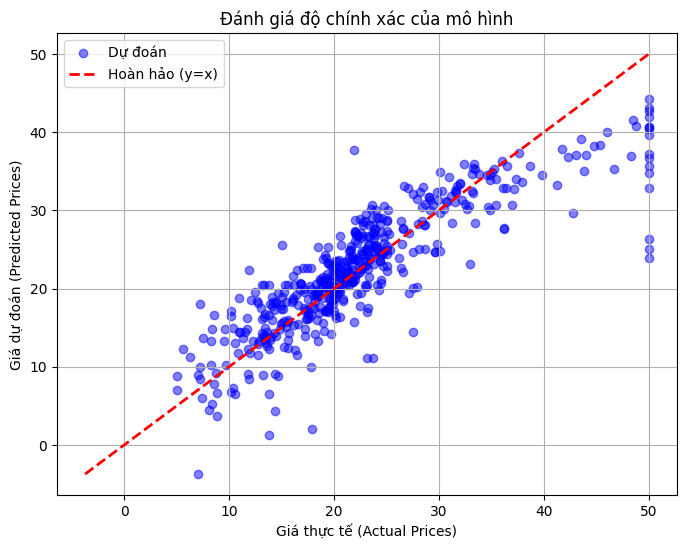

In [33]:
# 1. Dùng theta đã học để dự đoán lại toàn bộ dữ liệu
y_pred = predict(X_b, theta)

# 2. Thiết lập biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ các điểm dữ liệu (Xanh)
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Dự đoán')

# 3. Vẽ đường tham chiếu màu đỏ (Đường hoàn hảo y = x)
# Lấy giá trị nhỏ nhất và lớn nhất để vẽ đường chéo từ góc dưới lên góc trên
min_val = min(np.min(y), np.min(y_pred))
max_val = max(np.max(y), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Hoàn hảo (y=x)')

plt.xlabel('Giá thực tế (Actual Prices)')
plt.ylabel('Giá dự đoán (Predicted Prices)')
plt.title('Đánh giá độ chính xác của mô hình')
plt.legend()
plt.grid(True)
plt.show()

Đã tìm ra Theta tối ưu bằng Normal Equation!
Bias (theta[0]): 36.45948838509812
Các trọng số (weights) đầu tiên: [-0.10801136  0.04642046  0.02055863  2.68673382]


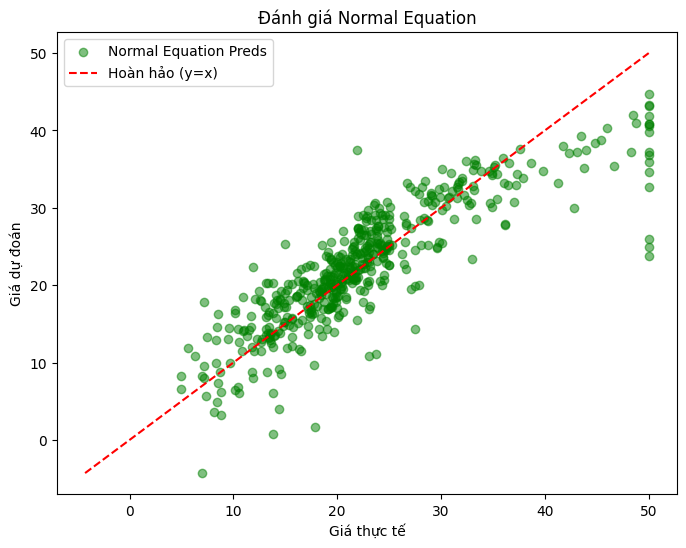

MSE Loss của Normal Equation: 21.89


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Chuẩn bị dữ liệu (Giữ nguyên) ---
# (Giả sử bạn vẫn giữ biến data từ các bước trước)
x_data = data.drop(['MEDV'], axis=1)
y_data = data['MEDV']

X = x_data.values
y = y_data.values

# LƯU Ý: Normal Equation KHÔNG bắt buộc phải Scale dữ liệu 
# (nhưng thêm bias là bắt buộc)
X_b = np.c_[np.ones((len(X), 1)), X]

# --- 2. ÁP DỤNG CÔNG THỨC NORMAL EQUATION ---
# Công thức: theta = inv(X.T * X) * X.T * y
# np.linalg.inv: Tính ma trận nghịch đảo

X_transpose = X_b.T
X_transpose_dot_X = X_transpose.dot(X_b)

# Kiểm tra xem ma trận có nghịch đảo được không (đôi khi bị lỗi nếu định thức = 0)
try:
    temp_1 = np.linalg.inv(X_transpose_dot_X)
    temp_2 = temp_1.dot(X_transpose)
    theta_normal = temp_2.dot(y)
    
    print("Đã tìm ra Theta tối ưu bằng Normal Equation!")
except np.linalg.LinAlgError:
    print("Ma trận không khả nghịch (Singular Matrix). Không dùng được Normal Equation.")
    theta_normal = None

# --- 3. Kết quả ---
if theta_normal is not None:
    print("Bias (theta[0]):", theta_normal[0])
    print("Các trọng số (weights) đầu tiên:", theta_normal[1:5]) # In thử vài cái

    # --- 4. Vẽ biểu đồ đánh giá (Thực tế vs Dự đoán) ---
    y_pred = X_b.dot(theta_normal)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y, y_pred, color='green', alpha=0.5, label='Normal Equation Preds')
    
    # Đường tham chiếu hoàn hảo
    min_val = min(np.min(y), np.min(y_pred))
    max_val = max(np.max(y), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Hoàn hảo (y=x)')
    
    plt.xlabel('Giá thực tế')
    plt.ylabel('Giá dự đoán')
    plt.title('Đánh giá Normal Equation')
    plt.legend()
    plt.show()

    # Tính MSE cuối cùng để so sánh với Gradient Descent
    mse = np.mean((y_pred - y)**2)
    print(f"MSE Loss của Normal Equation: {mse:.2f}")